In [6]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns #seaborn is built on top of matplotlib and allows you to easily produce prettier (and more complex) visualizations. Reference "Data Science from Scratch by Joel Grus" Page 65

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

file_path = r"C:\Users\Rashmi Rathi\Desktop\AI_ML_CLasses\projects\PROJECT 1-20260614T050628Z-3-001\PROJECT 1\Domain 1\MediCare_Readmission_Intelligence.csv"
df = pd.read_csv(file_path)

target = "readmission_flag"

print("Dataset loaded successfully")
print("--------------------------------------------")
print("Rows       :", df.shape[0])
print("Columns    :", df.shape[1])
print("Target     :", target)

if target in df.columns:
    print("Target column found successfully.")
else:
    print("ERROR: Target column NOT found.")
    print("\nAvailable columns:")
    print(df.columns.tolist())
    
#print("Dataset loaded successfully!")
#print("Shape:", df.shape) #identify Total data count and available variable type
#print("\nFirst 5 records:")
#print(df.head()) #detailed variable with headers

print("Target Distribution")
print("===================")

print(df[target].value_counts())

print("\nPercentage Distribution")
print("=======================")

print(
    (df[target].value_counts(normalize=True) * 100)
    .round(2)
)
print("Target Distribution")
print("===================")

print(df[target].value_counts())

print("\nPercentage Distribution")
print("=======================")

print(
    (df[target].value_counts(normalize=True) * 100)
    .round(2)
)
#print(df.info()) #Identified total 31 data columns

# Target variable: readmission_flag with output "0" or "1"
# Input Variable Set 1 (Demographic): age, gender, bmi, smoking_status, diabetes_flag
# Input Variable Set 2 (Prior Health Condition): hypertension, heart_disease, chronic_conditions 
# INput Variable Set 3 (Hospital Operational): previous previous_admissions_12m, length_of_stay_days, icu_admission_flag, emergency_admission_flag
# Input Variable Set 4 (Investigation): blood_glucose, cholesterol_level, hemoglobin, creatinine
# Input Variable Set 5 (Medications): high_risk_medication_flag, medication_changes_during_stay
# Input Variable Set 6 (Follow-up Flag Post Discharge): followup_scheduled_flag  patient_education_score  treatment_cost

##print(df.describe()) #Describe detailed values
##print(df.isnull().sum()) #Identify the Null (Cholesterol_level, andhemoglobin)
##print(df['readmission_flag'].value_counts()) #identified readmission_flag (The total of 0 is 32989 and Total of 1 is 17511)
print(df['readmission_flag'].value_counts(normalize=True)*100) #readmission_flag value normalization
# display(df.describe(include="all").T)



Dataset loaded successfully
--------------------------------------------
Rows       : 50500
Columns    : 31
Target     : readmission_flag
Target column found successfully.
Target Distribution
readmission_flag
0    32989
1    17511
Name: count, dtype: int64

Percentage Distribution
readmission_flag
0    65.32
1    34.68
Name: proportion, dtype: float64
Target Distribution
readmission_flag
0    32989
1    17511
Name: count, dtype: int64

Percentage Distribution
readmission_flag
0    65.32
1    34.68
Name: proportion, dtype: float64
readmission_flag
0    65.324752
1    34.675248
Name: proportion, dtype: float64


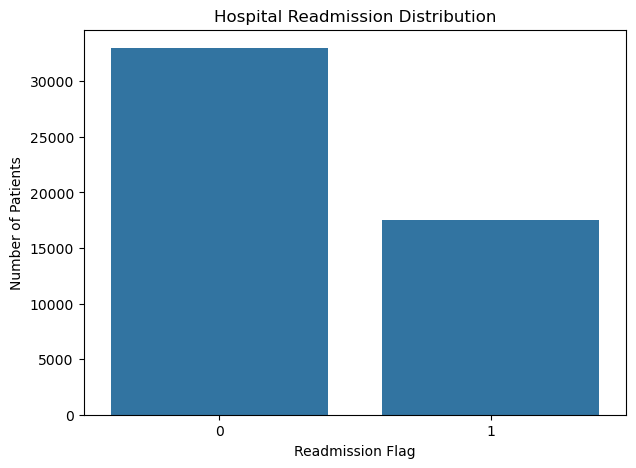

No Readmission: 65.32%
Readmission: 34.68%
Numerical Columns:
['patient_id', 'age', 'bmi', 'diabetes_flag', 'hypertension_flag', 'heart_disease_flag', 'chronic_conditions_count', 'previous_admissions_12m', 'length_of_stay_days', 'icu_admission_flag', 'emergency_admission_flag', 'number_of_procedures', 'blood_glucose', 'cholesterol_level', 'hemoglobin', 'creatinine', 'medications_count', 'high_risk_medication_flag', 'medication_changes_during_stay', 'followup_scheduled_flag', 'patient_education_score', 'treatment_cost', 'legacy_record_id', 'billing_reference_number', 'care_cluster_id', 'administrative_batch_id']

Categorical Columns:
['gender', 'smoking_status', 'discharge_destination', 'insurance_type']


In [7]:
# READMISSION DISTRIBUTION

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target)

plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmission Flag")
plt.ylabel("Number of Patients")

plt.show()

# READMISSION PERCENTAGE

readmission_percentage = (
    df[target].value_counts(normalize=True) * 100
)

print(
    f"No Readmission: {readmission_percentage.get(0, 0):.2f}%"
)

print(
    f"Readmission: {readmission_percentage.get(1, 0):.2f}%"
)

# IDENTIFY FEATURE TYPES

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Remove target from numerical features
if target in numerical_columns:
    numerical_columns.remove(target)

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


In [8]:
# REMOVE IDENTIFIER / ADMINISTRATIVE COLUMNS

identifier_columns = [
    "patient_id",
    "legacy_record_id",
    "billing_reference_number",
    "administrative_batch_id"
]

# Only remove columns that actually exist
columns_to_remove = [
    col for col in identifier_columns
    if col in df.columns
]

df_model = df.drop(columns=columns_to_remove)

print("Removed columns:")
print(columns_to_remove)

print("\nRemaining shape:", df_model.shape)


Removed columns:
['patient_id', 'legacy_record_id', 'billing_reference_number', 'administrative_batch_id']

Remaining shape: (50500, 27)


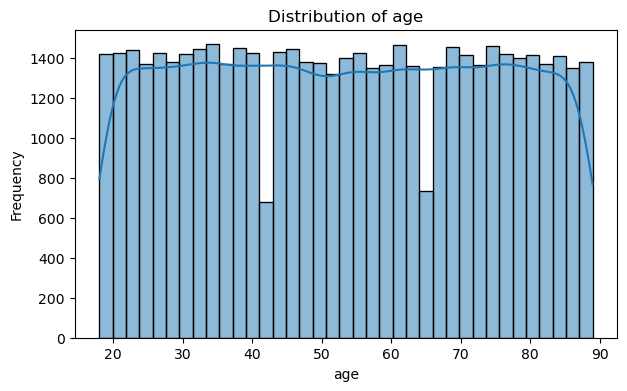

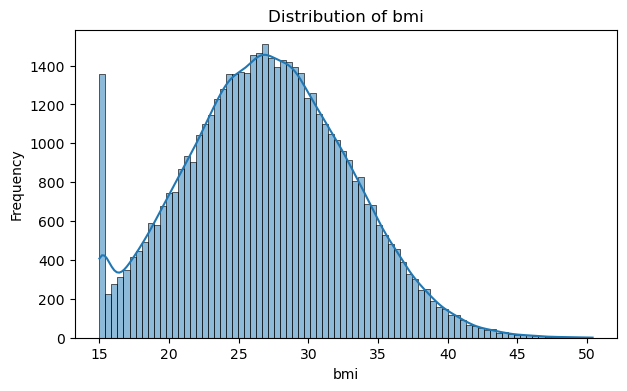

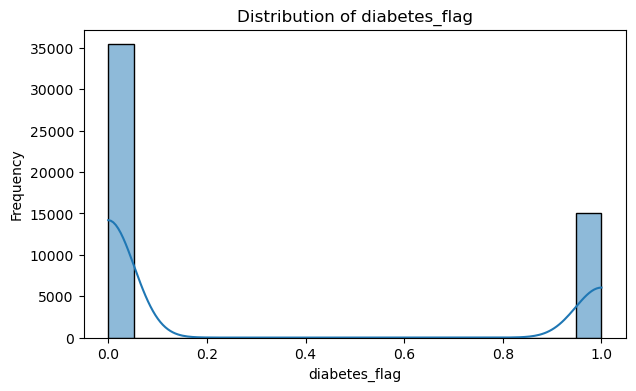

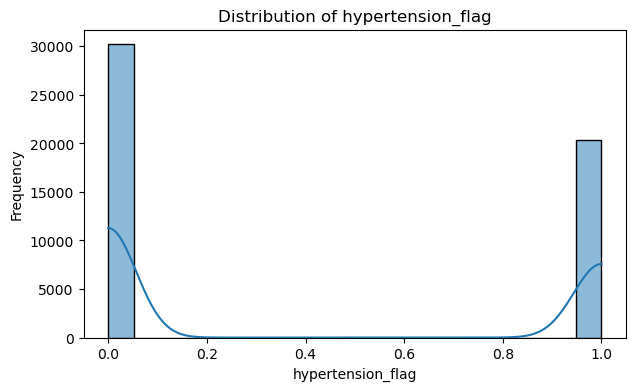

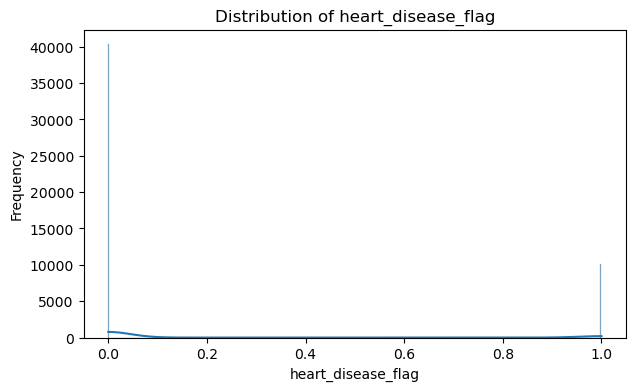

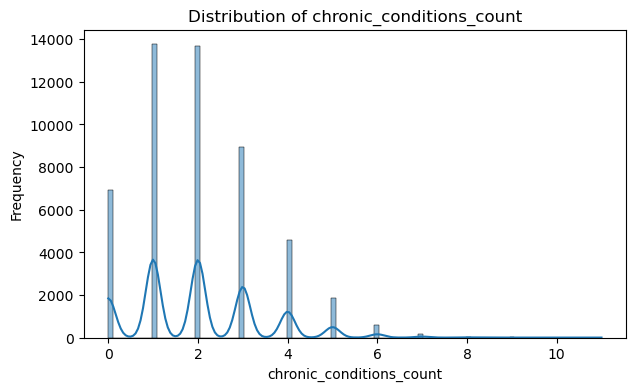

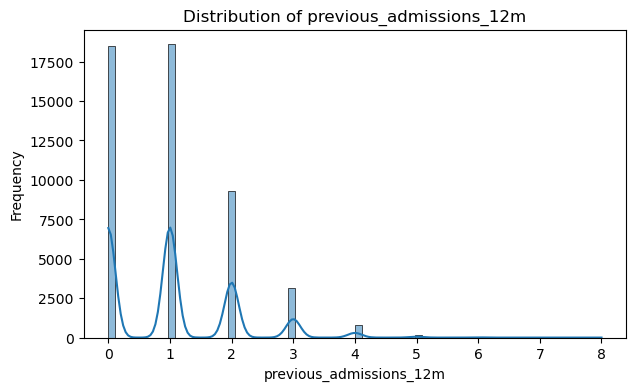

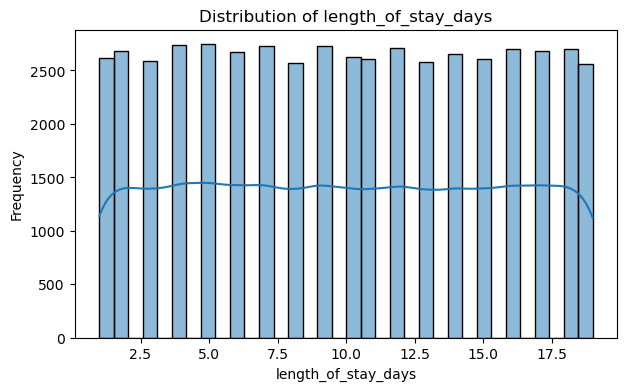

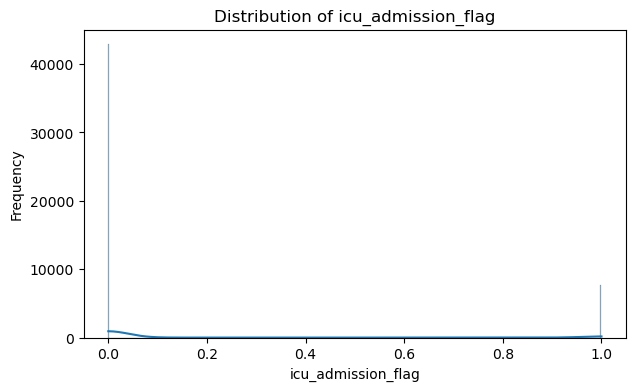

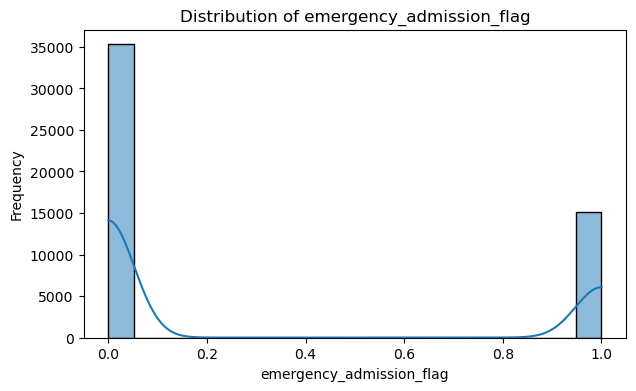

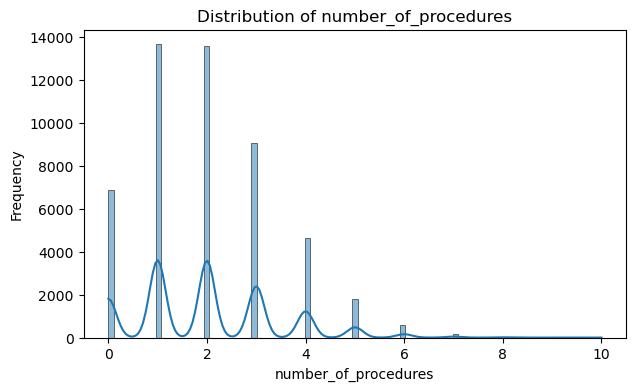

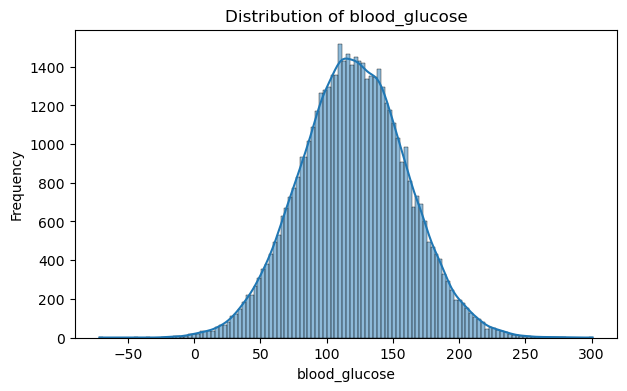

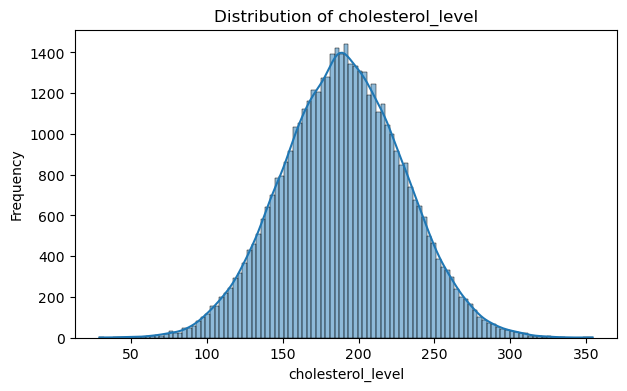

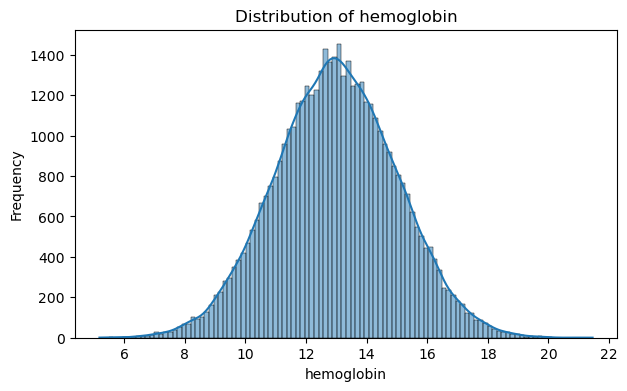

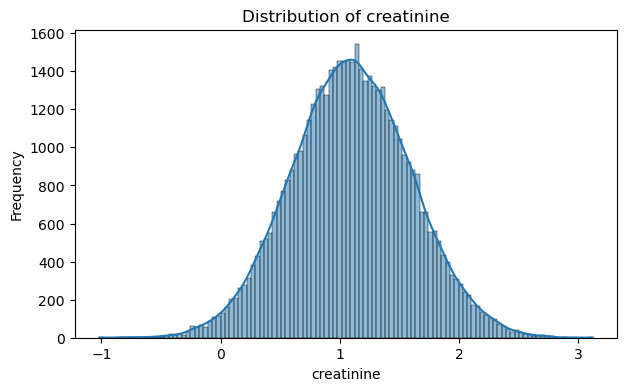

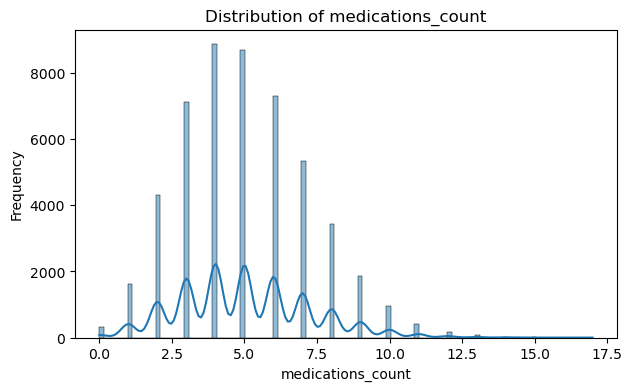

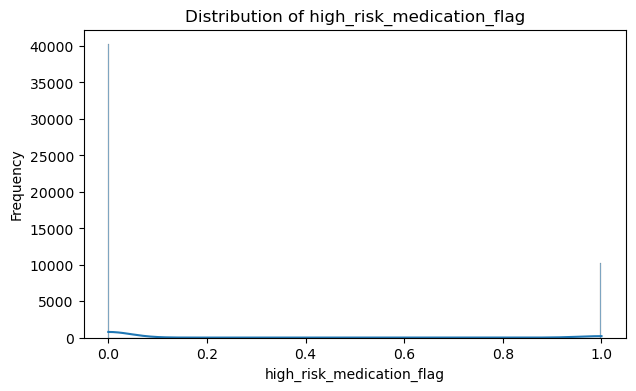

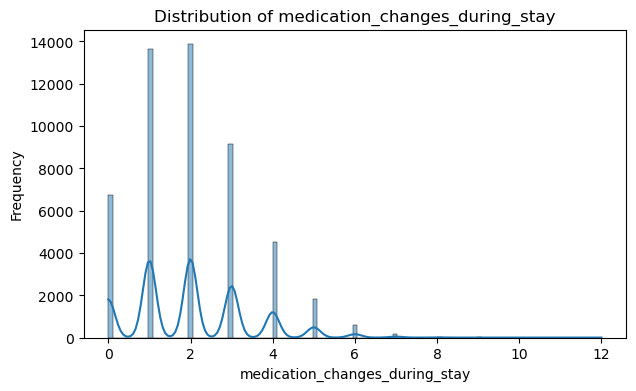

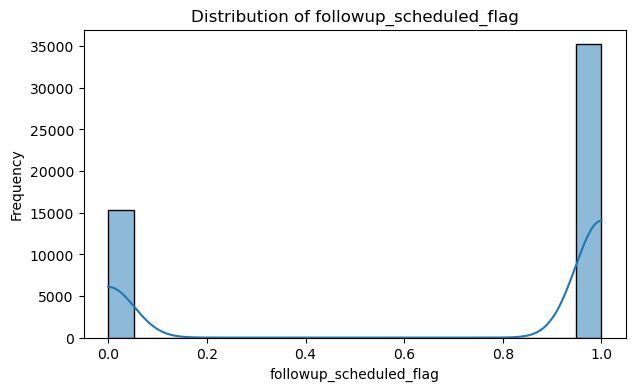

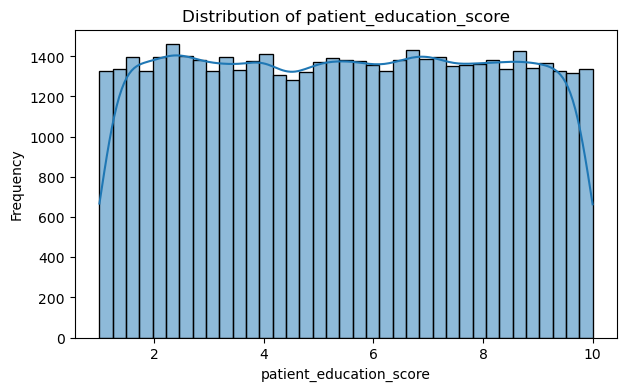

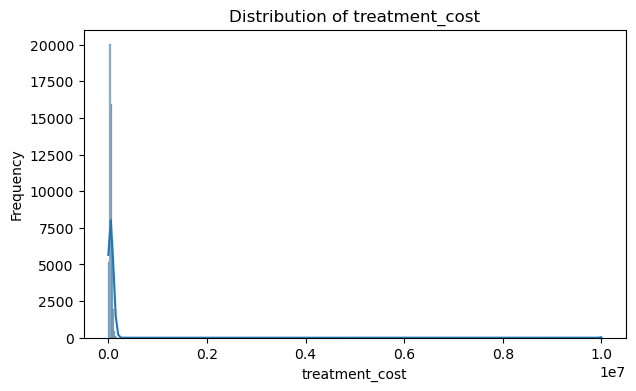

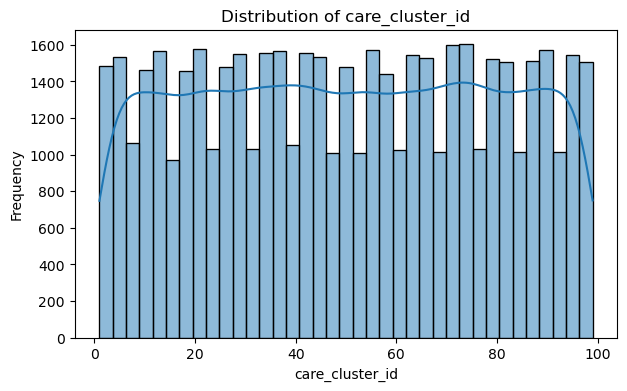

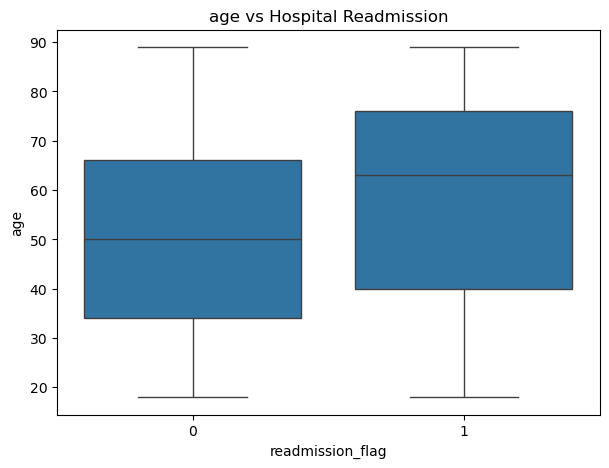

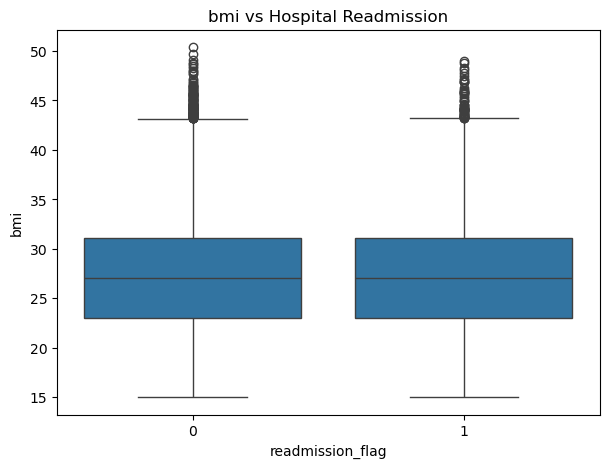

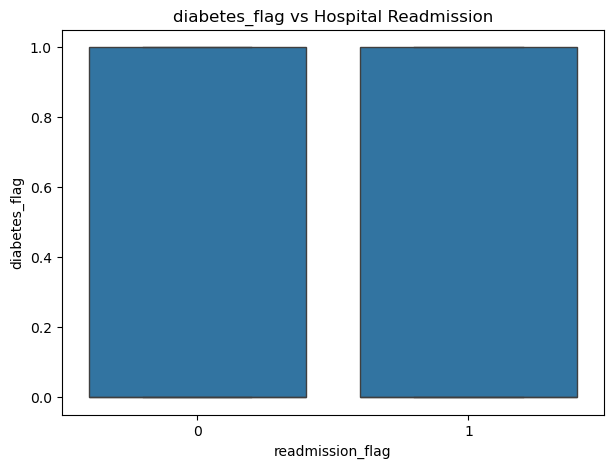

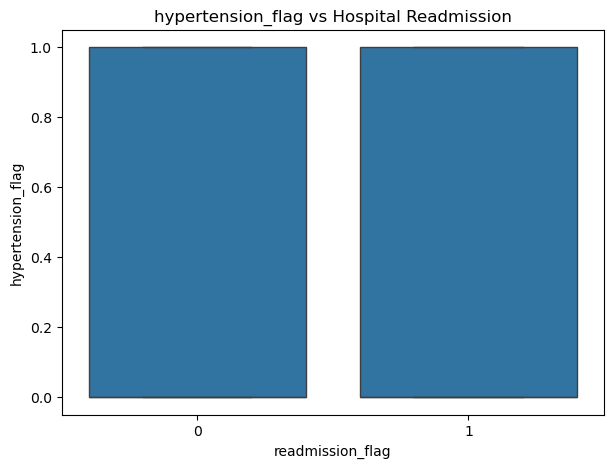

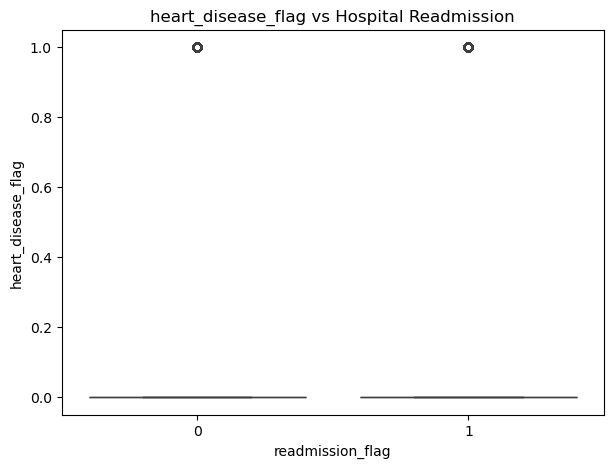

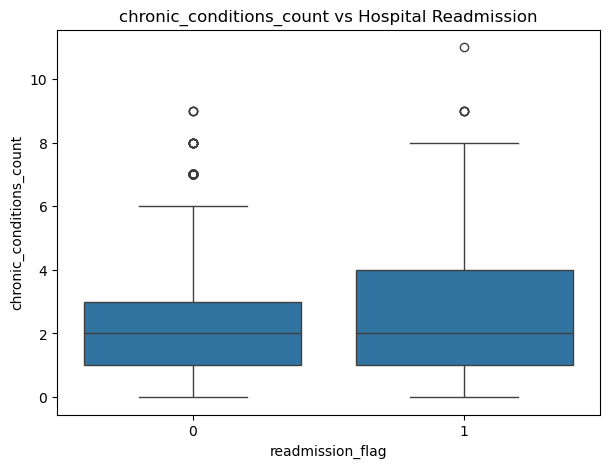

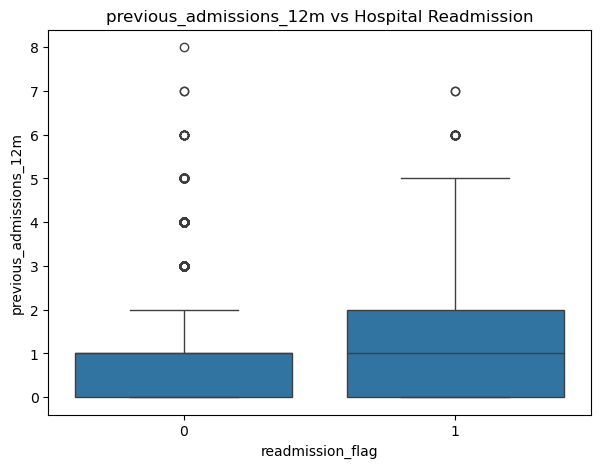

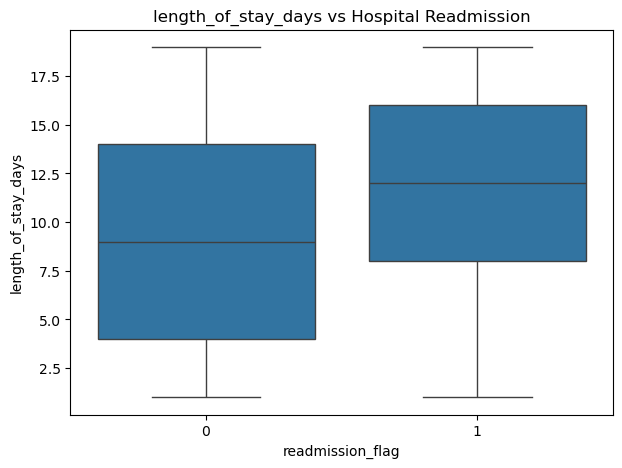

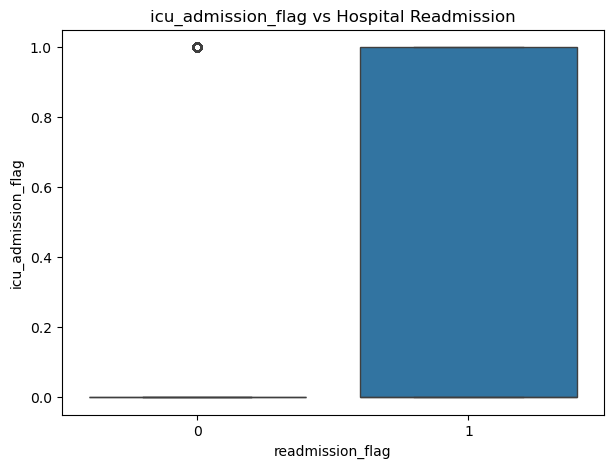

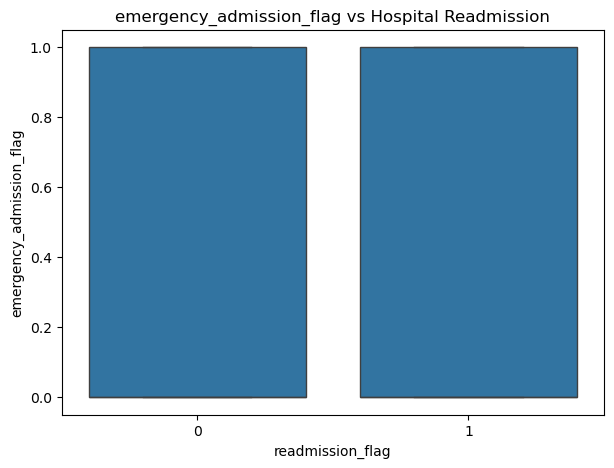

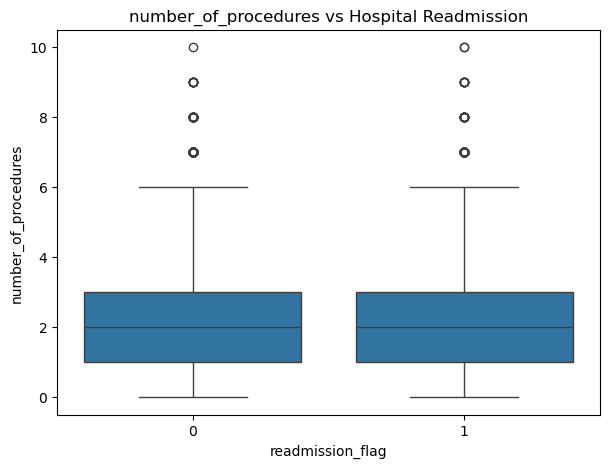

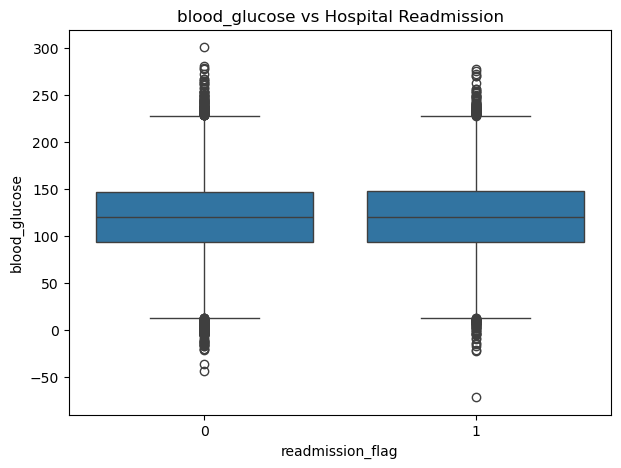

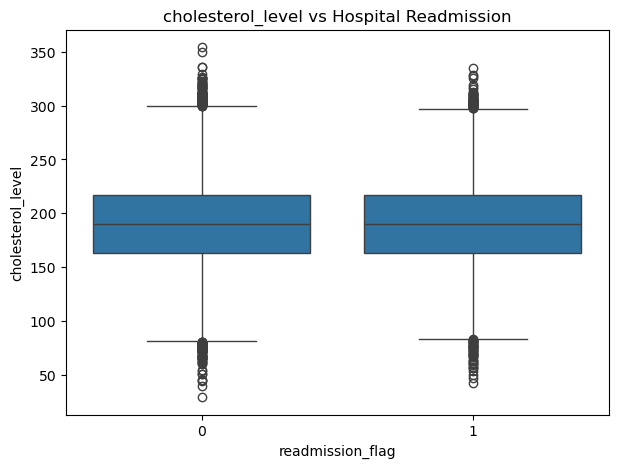

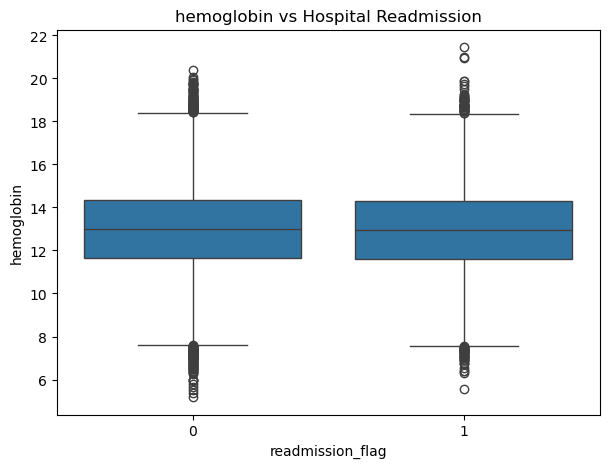

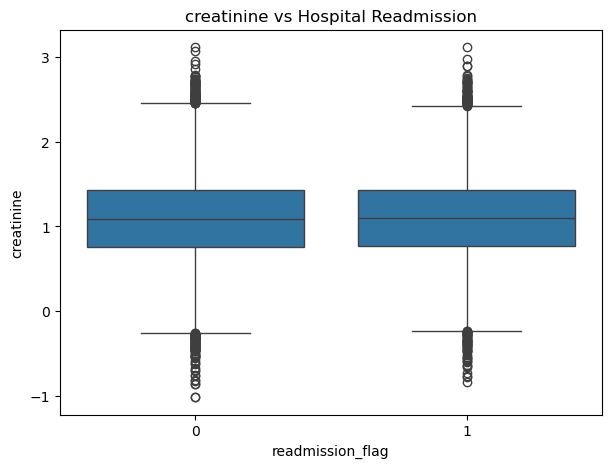

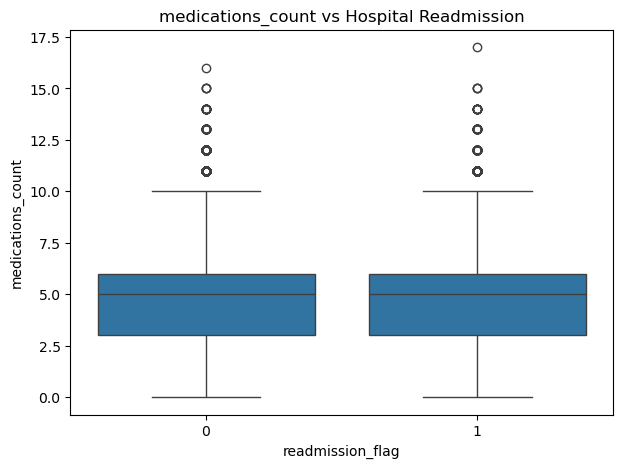

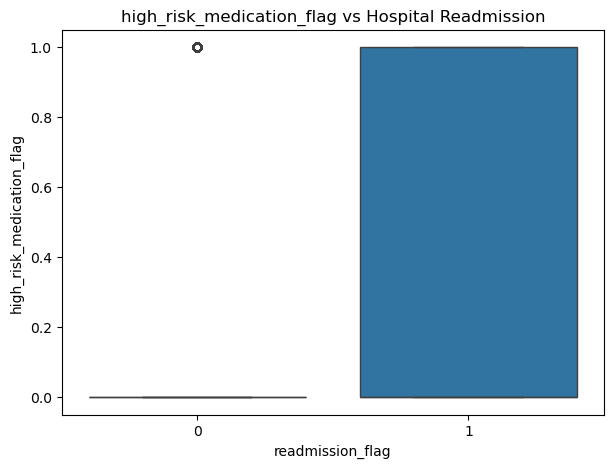

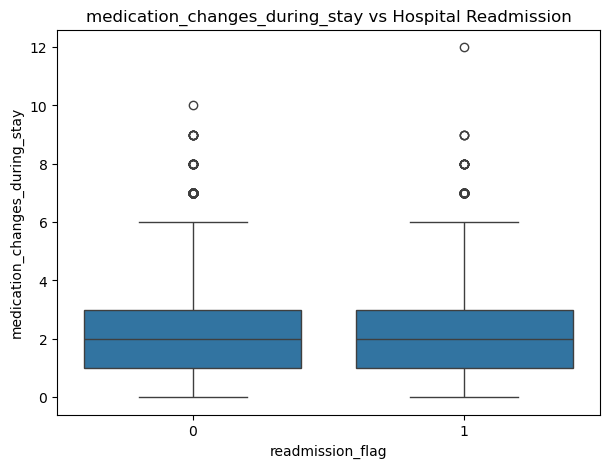

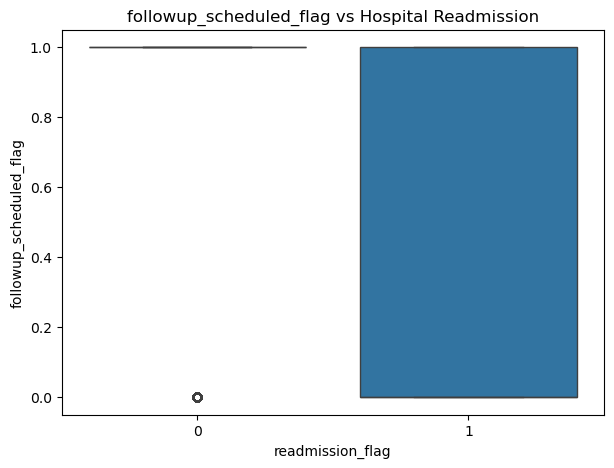

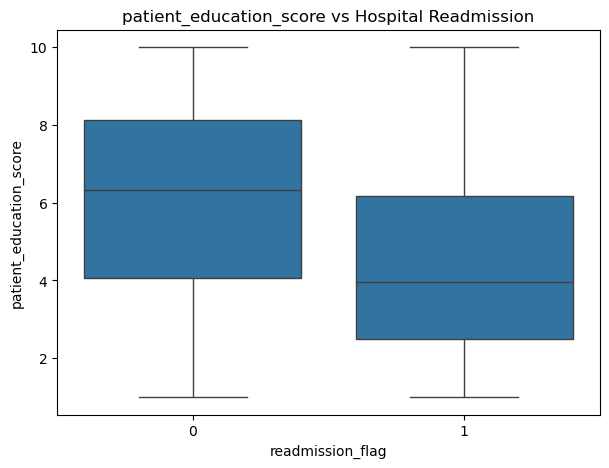

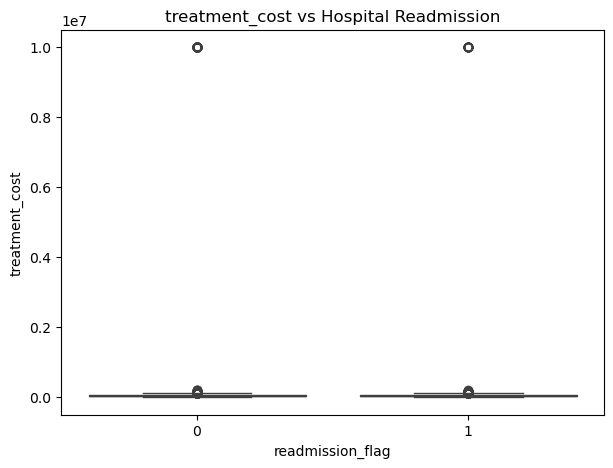

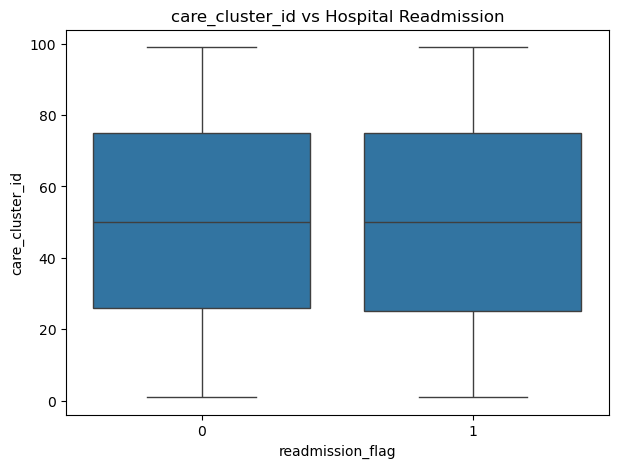

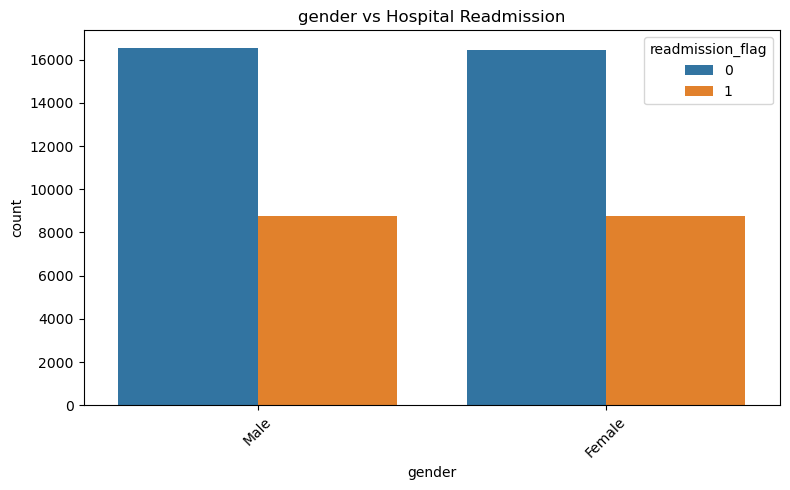

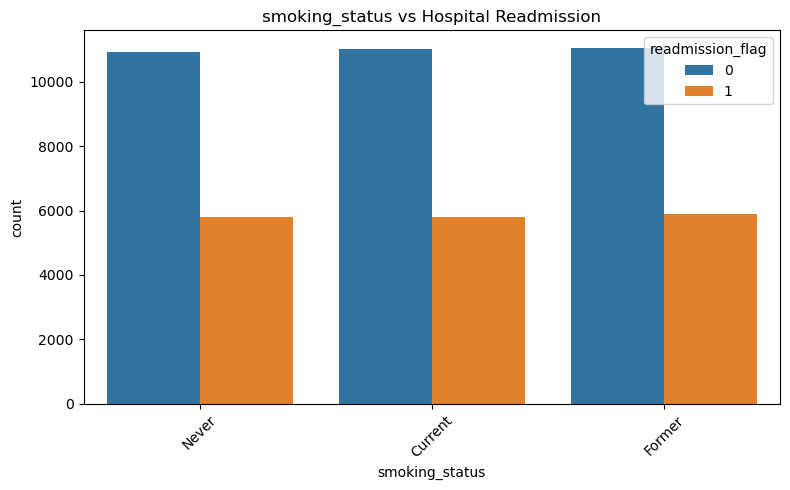

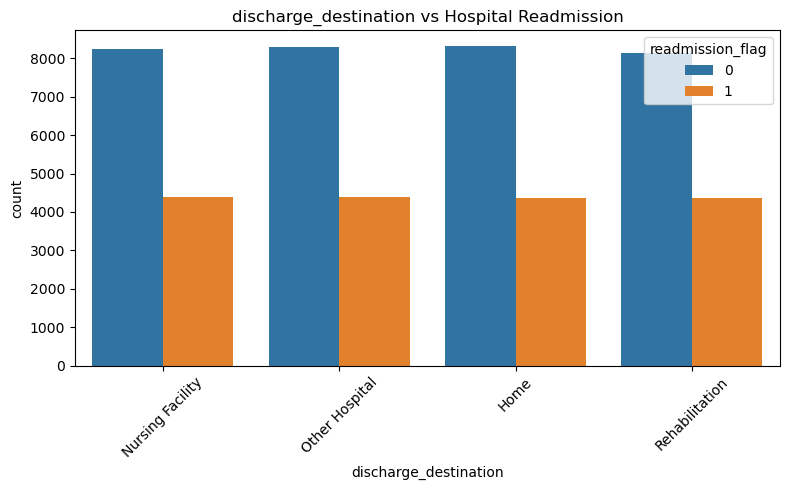

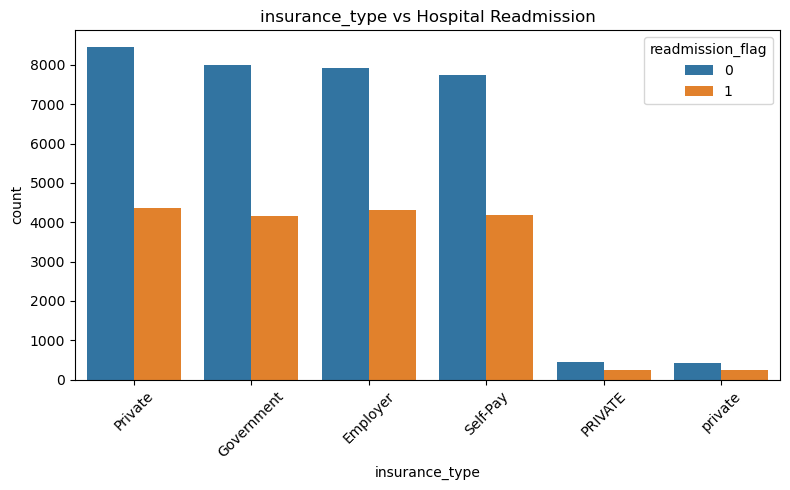

In [9]:
# NUMERICAL VARIABLE DISTRIBUTIONS

numeric_cols = df_model.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_cols = [
    col for col in numeric_cols
    if col != target
]

for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df_model,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

# NUMERICAL VARIABLES VS READMISSION

for col in numeric_cols:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df_model,
        x=target,
        y=col
    )

    plt.title(f"{col} vs Hospital Readmission")

    plt.show()

# CATEGORICAL VARIABLES VS READMISSION
categorical_cols = df_model.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_cols:

    if df_model[col].nunique() <= 15:

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df_model,
            x=col,
            hue=target
        )

        plt.title(f"{col} vs Hospital Readmission")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()


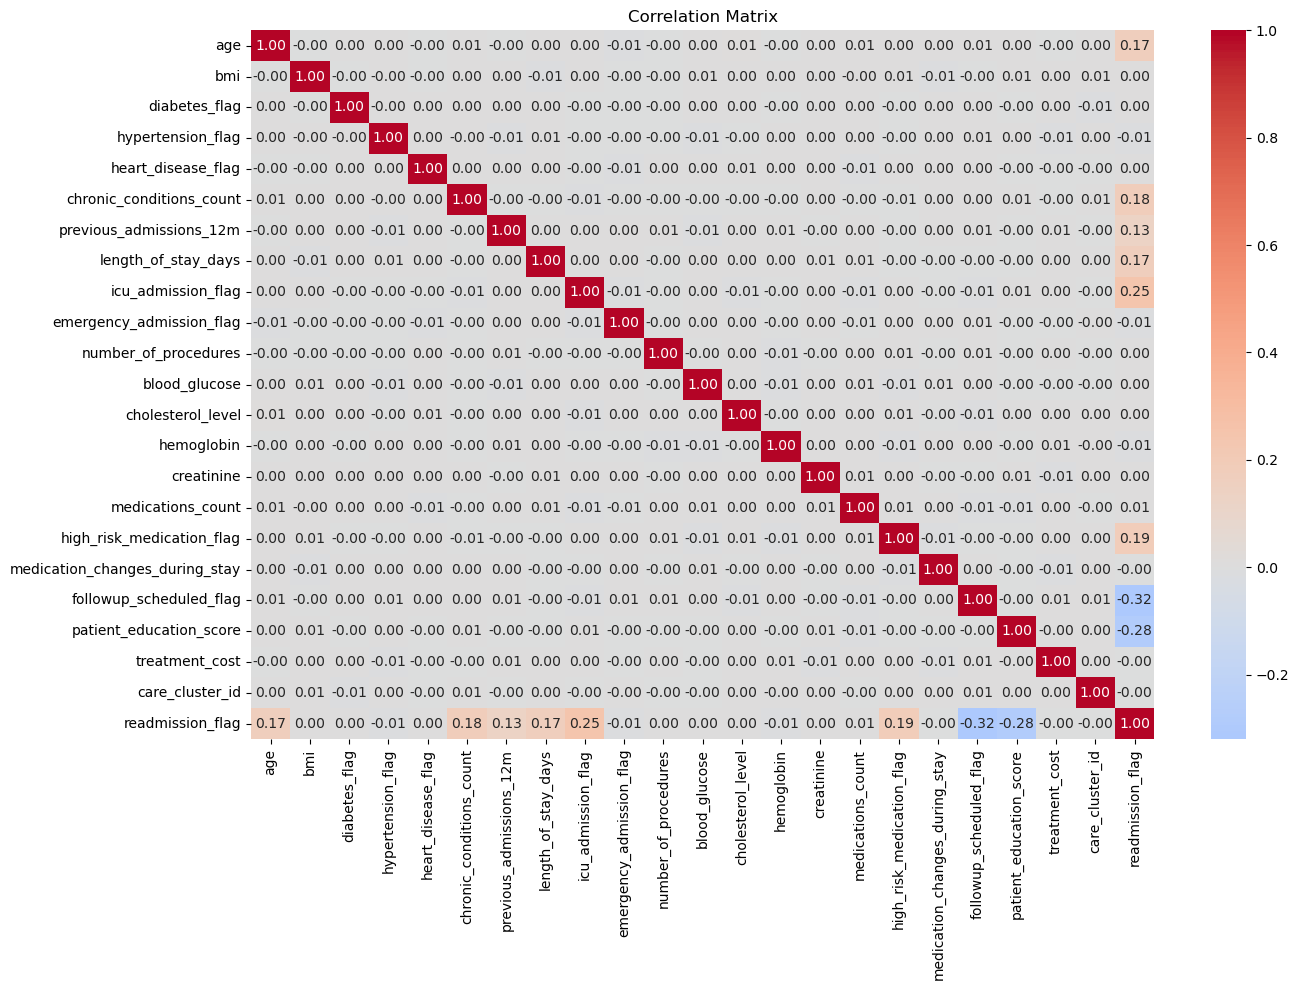

X shape: (50500, 26)
y shape: (50500,)

Target distribution:
readmission_flag
0    32989
1    17511
Name: count, dtype: int64


In [11]:
# CORRELATION MATRIX

numeric_df = df_model.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# DEFINE FEATURES AND TARGET

X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())



In [12]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Training records: 40400
Testing records: 10100


In [13]:
# PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully")


Numerical features: ['age', 'bmi', 'diabetes_flag', 'hypertension_flag', 'heart_disease_flag', 'chronic_conditions_count', 'previous_admissions_12m', 'length_of_stay_days', 'icu_admission_flag', 'emergency_admission_flag', 'number_of_procedures', 'blood_glucose', 'cholesterol_level', 'hemoglobin', 'creatinine', 'medications_count', 'high_risk_medication_flag', 'medication_changes_during_stay', 'followup_scheduled_flag', 'patient_education_score', 'treatment_cost', 'care_cluster_id']
Categorical features: ['gender', 'smoking_status', 'discharge_destination', 'insurance_type']
Preprocessing pipeline created successfully


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

display(results_df)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.855743,0.861691,0.695603,0.769790,0.928791
1,Random Forest,0.853762,0.752935,0.860651,0.803198,0.926265
2,Decision Tree,0.852475,0.750373,0.860937,0.801862,0.921885
3,Logistic Regression,0.808614,0.753637,0.665620,0.706899,0.878151


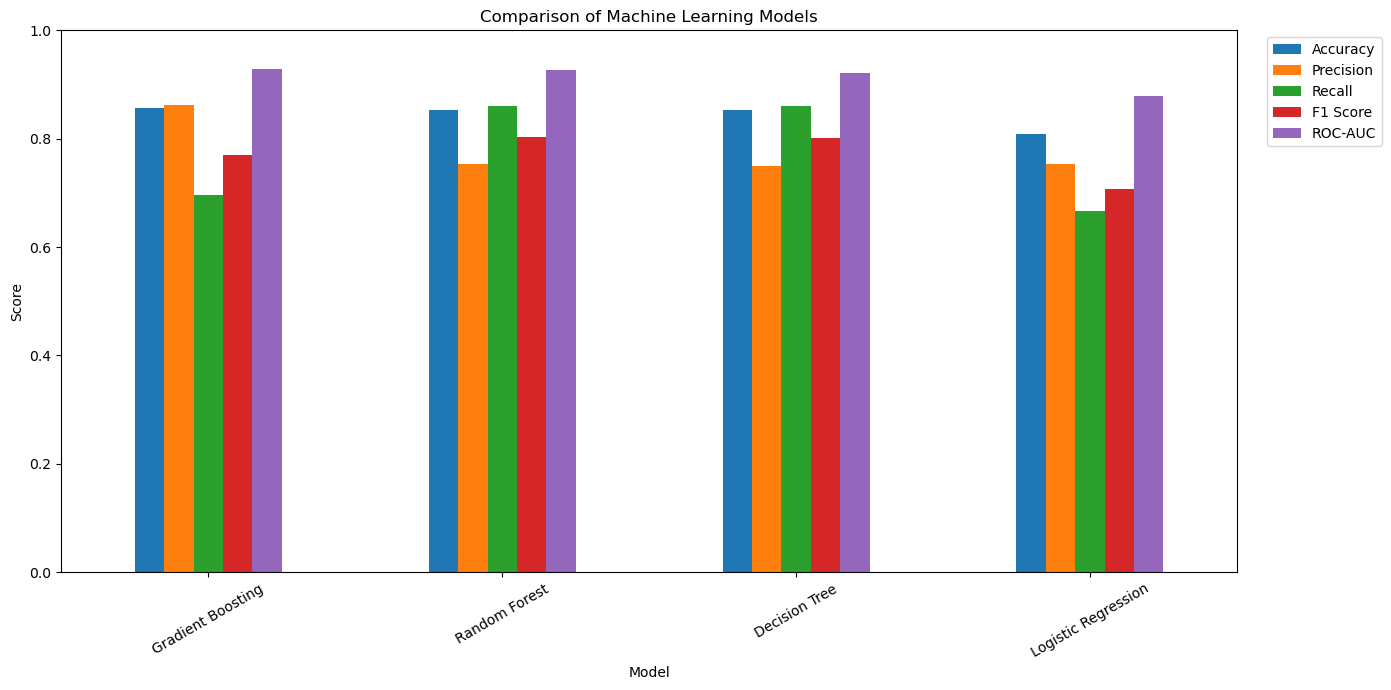

In [22]:
# MODEL COMPARISON
results_plot = results_df.set_index("Model")

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()


In [23]:
# SELECT BEST MODEL Confusion Matrix 

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: Gradient Boosting


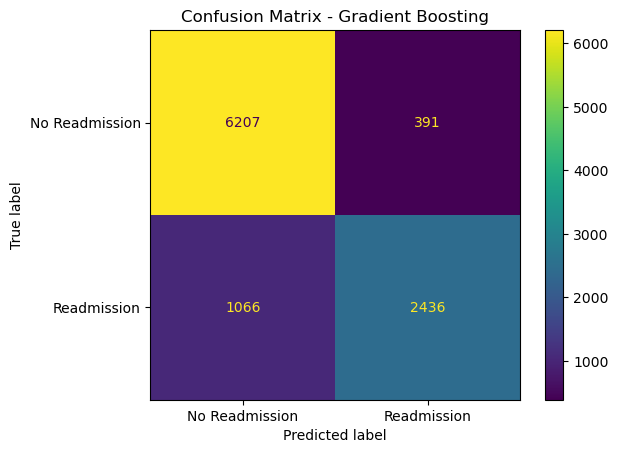

In [24]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "Readmission"]
)

disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()


In [25]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Readmission",
            "Readmission"
        ],
        zero_division=0
    )
)



                precision    recall  f1-score   support

No Readmission       0.85      0.94      0.89      6598
   Readmission       0.86      0.70      0.77      3502

      accuracy                           0.86     10100
     macro avg       0.86      0.82      0.83     10100
  weighted avg       0.86      0.86      0.85     10100



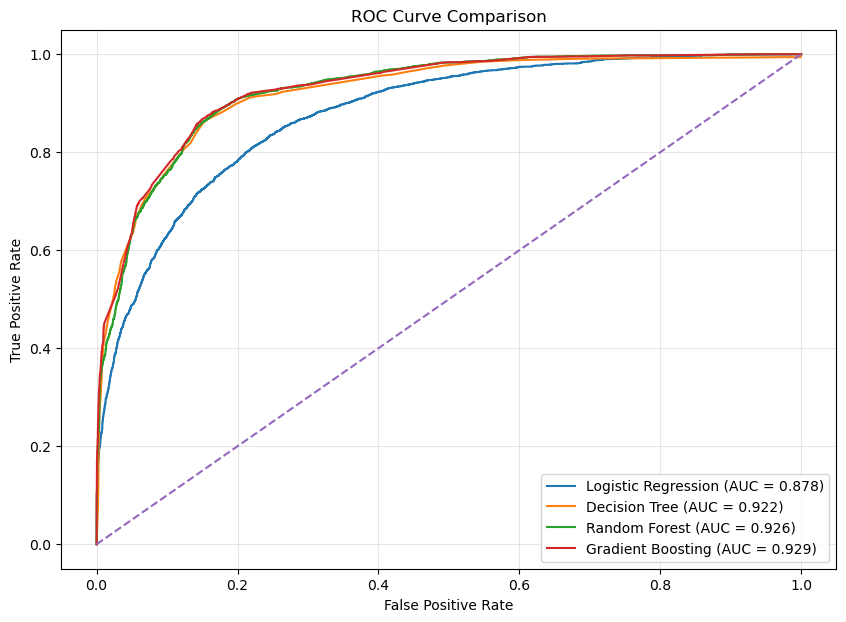

In [26]:
# ROC CURVE

from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, model in models.items():

    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


In [27]:
# RANDOM FOREST FEATURE IMPORTANCE

rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_classifier = random_forest_model.named_steps[
    "classifier"
]

feature_names = rf_preprocessor.get_feature_names_out()

importance = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))


,Feature,Importance
19,num__patient_education_score,0.212293
18,num__followup_scheduled_flag,0.170387
5,num__chronic_conditions_count,0.098161
8,num__icu_admission_flag,0.095841
0,num__age,0.081950
7,num__length_of_stay_days,0.078377
16,num__high_risk_medication_flag,0.053434
6,num__previous_admissions_12m,0.049990
20,num__treatment_cost,0.016262
14,num__creatinine,0.016070


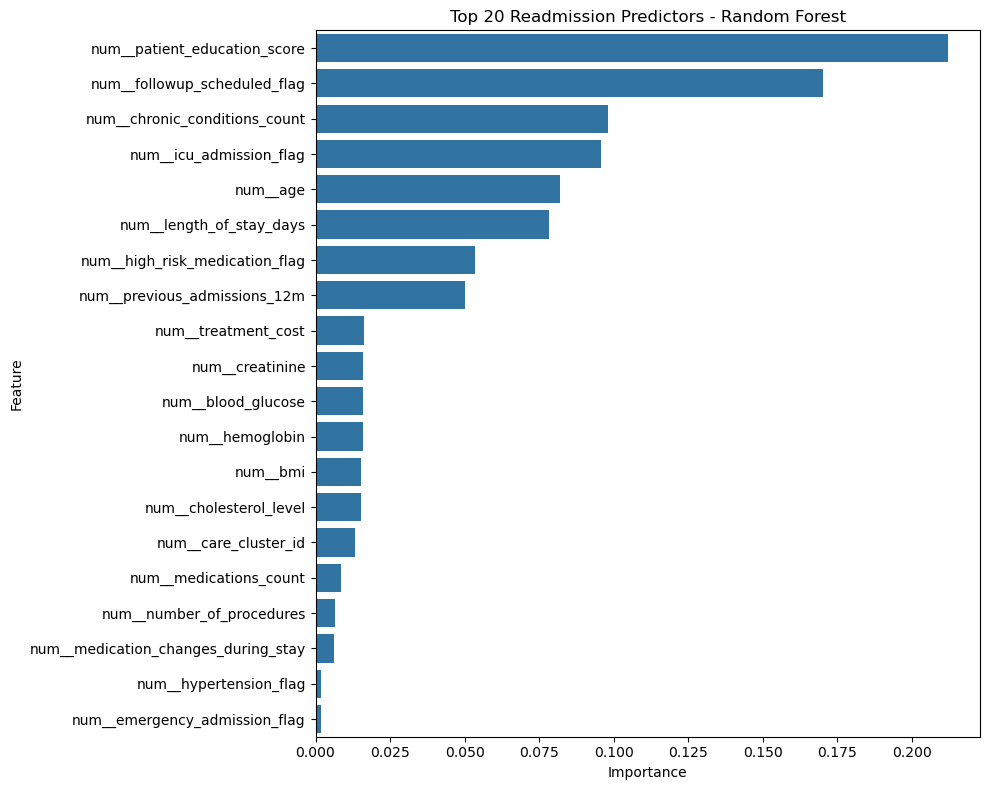

In [28]:
# TOP 20 FEATURE IMPORTANCE

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Readmission Predictors - Random Forest")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()


In [30]:
# PATIENT READMISSION RISK

test_predictions = X_test.copy()

test_predictions["Actual_Readmission"] = y_test.values

test_predictions["Predicted_Readmission"] = (
    best_model.predict(X_test)
)

test_predictions["Readmission_Probability"] = (
    best_model.predict_proba(X_test)[:, 1]
)

test_predictions[
    "Risk_Level"
] = pd.cut(
    test_predictions[
        "Readmission_Probability"
    ],
    bins=[-0.01, 0.30, 0.70, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

display(
    test_predictions[
        [
            "Actual_Readmission",
            "Predicted_Readmission",
            "Readmission_Probability",
            "Risk_Level"
        ]
    ].head(20)
)

,Actual_Readmission,Predicted_Readmission,Readmission_Probability,Risk_Level
48247,0,0,0.157746,Low Risk
15555,0,0,0.316890,Medium Risk
10639,0,0,0.170293,Low Risk
15434,1,0,0.316890,Medium Risk
46094,0,0,0.057356,Low Risk
32318,0,0,0.157746,Low Risk
16098,0,0,0.157746,Low Risk
35070,0,0,0.170293,Low Risk
38764,1,1,0.785251,High Risk
44694,0,0,0.208338,Low Risk


Risk_Level
Low Risk       5597
Medium Risk    2875
High Risk      1628
Name: count, dtype: int64

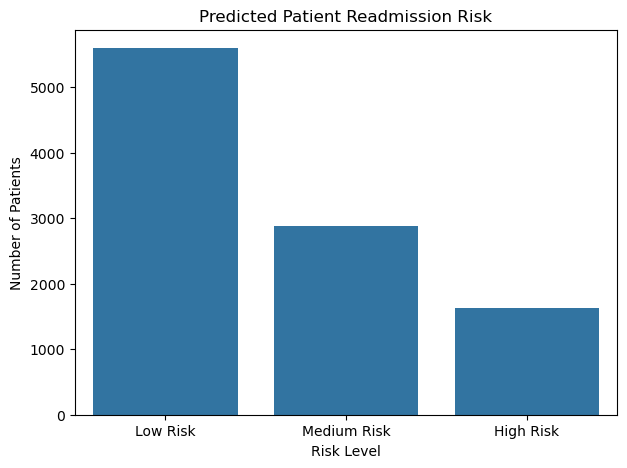

In [31]:
# PATIENT RISK DISTRIBUTION

risk_distribution = (
    test_predictions["Risk_Level"]
    .value_counts()
)

display(risk_distribution)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=test_predictions,
    x="Risk_Level",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Predicted Patient Readmission Risk")

plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.show()


In [32]:
# HIGH-RISK PATIENTS

high_risk_patients = test_predictions[
    test_predictions["Risk_Level"] == "High Risk"
].copy()

print(
    "Number of high-risk patients:",
    len(high_risk_patients)
)

display(high_risk_patients.head(20))


Number of high-risk patients: 1628


,age,gender,bmi,smoking_status,diabetes_flag,hypertension_flag,heart_disease_flag,chronic_conditions_count,previous_admissions_12m,length_of_stay_days,icu_admission_flag,emergency_admission_flag,number_of_procedures,blood_glucose,cholesterol_level,hemoglobin,creatinine,medications_count,high_risk_medication_flag,medication_changes_during_stay,followup_scheduled_flag,discharge_destination,patient_education_score,insurance_type,treatment_cost,care_cluster_id,Actual_Readmission,Predicted_Readmission,Readmission_Probability,Risk_Level
38764,85,Male,21.682775,Current,1,0,1,2,1,11,0,0,4,122.756011,174.305730,11.760016,1.567336,1,1,3,0,Other Hospital,5.254290,Private,53258.460286,70,1,1,0.785251,High Risk
8757,35,Female,31.439708,Former,0,0,0,0,5,18,0,1,5,95.857877,173.404764,14.355551,2.026572,5,0,1,0,Other Hospital,4.801847,Private,29898.802440,85,0,1,0.934821,High Risk
1835,89,Female,23.713978,Former,1,1,1,4,0,18,0,1,2,138.146475,247.080185,12.863420,0.107616,2,0,2,1,Nursing Facility,2.104733,Private,67540.404237,51,1,1,0.898787,High Risk
45868,59,Male,31.615252,Never,0,0,0,4,0,2,0,0,0,158.632228,199.637263,12.328885,1.061999,6,0,4,0,Home,4.488914,Self-Pay,23426.352813,27,1,1,0.788738,High Risk
8109,45,Male,27.744781,Never,0,0,0,5,1,16,0,0,4,75.375063,119.186172,12.957998,0.804557,5,1,1,1,Home,1.437151,Self-Pay,35331.510352,27,1,1,0.893887,High Risk
35142,80,Female,28.362016,Former,1,0,0,1,1,12,1,0,5,80.963109,196.061320,15.002130,1.699633,7,0,3,0,Other Hospital,9.440146,Self-Pay,52345.684265,7,1,1,0.870336,High Risk
25194,75,Male,31.007488,Never,0,0,0,1,3,3,0,0,1,119.072451,296.688774,12.605321,1.919014,3,0,3,0,Home,3.224484,Self-Pay,45782.917819,68,1,1,0.899128,High Risk
21010,66,Female,25.404691,Never,0,0,0,6,0,16,0,0,2,121.894277,173.323177,10.383964,0.572390,4,0,2,0,Rehabilitation,4.390078,Government,37098.654504,61,1,1,0.973141,High Risk
41597,69,Male,24.197903,Current,1,0,1,0,4,9,1,0,3,119.782941,NaN,10.833059,0.332537,9,1,0,1,Home,4.590985,Self-Pay,44967.159377,74,1,1,0.992650,High Risk
8691,50,Male,27.180977,Never,0,1,0,5,3,18,1,1,1,126.607985,206.087674,NaN,0.837390,3,1,3,1,Home,7.972798,Government,14066.923407,79,1,1,0.940159,High Risk


In [33]:
print("""
========================================================
HOSPITAL READMISSION MANAGEMENT RECOMMENDATIONS
========================================================

1. HIGH-RISK PATIENT IDENTIFICATION
   Use the ML model to identify patients with a high
   probability of readmission before discharge.

2. ENHANCED DISCHARGE PLANNING
   High-risk patients should receive enhanced discharge
   planning and clearly documented post-discharge instructions.

3. FOLLOW-UP MANAGEMENT
   Ensure follow-up appointments are scheduled before
   discharge for high-risk patients.

4. MEDICATION REVIEW
   Patients with multiple medications or medication
   changes should receive medication reconciliation
   and counselling.

5. CHRONIC CONDITION MANAGEMENT
   Patients with multiple chronic conditions should
   receive targeted post-discharge monitoring.

6. POST-DISCHARGE MONITORING
   Consider telephone follow-ups, telemedicine,
   remote monitoring, or care coordinator intervention.

7. PATIENT EDUCATION
   Improve discharge education for patients identified
   as having elevated readmission risk.

8. OPERATIONAL PLANNING
   Hospital administration can use predicted risk
   patterns to plan care coordination resources.

9. MODEL MONITORING
   The model should be periodically retrained using
   new hospital data and monitored for performance
   degradation.

10. HUMAN OVERSIGHT
    The prediction should support clinical and
    operational decision-making rather than replace
    clinical judgement.
========================================================
""")



HOSPITAL READMISSION MANAGEMENT RECOMMENDATIONS

1. HIGH-RISK PATIENT IDENTIFICATION
   Use the ML model to identify patients with a high
   probability of readmission before discharge.

2. ENHANCED DISCHARGE PLANNING
   High-risk patients should receive enhanced discharge
   planning and clearly documented post-discharge instructions.

3. FOLLOW-UP MANAGEMENT
   Ensure follow-up appointments are scheduled before
   discharge for high-risk patients.

4. MEDICATION REVIEW
   Patients with multiple medications or medication
   changes should receive medication reconciliation
   and counselling.

5. CHRONIC CONDITION MANAGEMENT
   Patients with multiple chronic conditions should
   receive targeted post-discharge monitoring.

6. POST-DISCHARGE MONITORING
   Consider telephone follow-ups, telemedicine,
   remote monitoring, or care coordinator intervention.

7. PATIENT EDUCATION
   Improve discharge education for patients identified
   as having elevated readmission risk.

8. OPERATIONAL 

In [34]:
# SAVE RESULTS

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

test_predictions.to_csv(
    "patient_readmission_predictions.csv",
    index=False
)

print("Results saved successfully.")


Results saved successfully.


In [35]:
# SAVE BEST MODEL

import joblib

joblib.dump(
    best_model,
    "best_readmission_prediction_model.pkl"
)

print(
    f"Best model ({best_model_name}) saved successfully."
)


Best model (Gradient Boosting) saved successfully.


In [36]:
# FINAL PROJECT SUMMARY

print("===================================================")
print("       MEDICARE READMISSION INTELLIGENCE")
print("===================================================")

print(f"Dataset Size       : {df.shape}")
print(f"Best Model         : {best_model_name}")

best_row = results_df.iloc[0]

print(
    f"Accuracy           : {best_row['Accuracy']:.4f}"
)

print(
    f"Precision          : {best_row['Precision']:.4f}"
)

print(
    f"Recall             : {best_row['Recall']:.4f}"
)

print(
    f"F1 Score           : {best_row['F1 Score']:.4f}"
)

print(
    f"ROC-AUC            : {best_row['ROC-AUC']:.4f}"
)

print("===================================================")

       MEDICARE READMISSION INTELLIGENCE
Dataset Size       : (50500, 31)
Best Model         : Gradient Boosting
Accuracy           : 0.8557
Precision          : 0.8617
Recall             : 0.6956
F1 Score           : 0.7698
ROC-AUC            : 0.9288
